In [19]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [20]:
ele_price = pd.read_excel('/Users/geng44/Desktop/project/Average_retail_price_of_electricity.xlsx')

ff_price = pd.read_excel('/Users/geng44/Desktop/project/Average_cost_of_fossil_fuels_for_electricity_generation.xlsx')

ff_receipt = pd.read_excel('/Users/geng44/Desktop/project/Receipts_of_fossil_fuels_by_electricity_plants_for_all_sectors.xlsx')

net_gene = pd.read_excel('/Users/geng44/Desktop/project/Net_generation.xlsx')

In [21]:
ele_price_T = ele_price.T
ele_price_T.columns = ele_price_T.iloc[0]
ele_price_T = ele_price_T[1:]

In [22]:
ff_price_T = ff_price.T
ff_price_T.columns = ff_price_T.iloc[0]
ff_price_T = ff_price_T[1:]

In [23]:
ff_receipt_T = ff_receipt.T
ff_receipt_T.columns = ff_receipt_T.iloc[0]
ff_receipt_T = ff_receipt_T[1:]

In [24]:
net_gene_T = net_gene.T
net_gene_T.columns = net_gene_T.iloc[0]
net_gene_T = net_gene_T[1:]
net_gene_T.fillna(0, inplace=True)

/var/folders/ty/9rmz2lcd2p35hd3wb4_5v6_m0000gs/T/ipykernel_48554/1080020301.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  net_gene_T.fillna(0, inplace=True)


In [25]:
ff_receipt_T

description,coal,bituminous coal,subbituminous coal,lignite coal,petroleum liquids,petroleum coke,natural gas
2008-01-01 00:00:00,87608,37885,42373,5985,4965,628,639424
2008-02-01 00:00:00,84048,36201,41218,5406,3852,422,538625
2008-03-01 00:00:00,87826,39224,42789,4799,3721,630,563326
2008-04-01 00:00:00,86916,38415,42412,4898,6041,612,569441
2008-05-01 00:00:00,88716,40135,41773,5622,4102,516,575650
...,...,...,...,...,...,...,...
2025-08-01 00:00:00,35625,11011,20918,3192,1527,127,1288923
2025-09-01 00:00:00,33684,11084,19635,2601,1039,84,1125996
2025-10-01 00:00:00,34535,11630,19754,2942,1154,133,971380
2025-11-01 00:00:00,33085,10884,18797,3031,1365,86,896400


In [26]:
ff_price_T

description,coal,bituminous coal,subbituminous coal,lignite coal,petroleum liquids,petroleum coke,natural gas
2008-01-01 00:00:00,1.88,2.2,1.55,1.33,14.61,1.62,8.19
2008-02-01 00:00:00,1.89,2.22,1.55,1.37,15.03,1.82,8.58
2008-03-01 00:00:00,1.93,2.25,1.57,1.38,14.67,1.82,9.25
2008-04-01 00:00:00,1.97,2.33,1.57,1.42,14.65,1.79,9.89
2008-05-01 00:00:00,2.04,2.41,1.63,1.37,17.13,1.96,10.73
...,...,...,...,...,...,...,...
2025-08-01 00:00:00,2.41,3.01,2.06,1.76,16.82,2.9,3.17
2025-09-01 00:00:00,2.41,2.97,2.03,1.94,16.25,2.73,3.04
2025-10-01 00:00:00,2.39,2.95,1.99,2.0,16.4,2.66,3.08
2025-11-01 00:00:00,2.39,2.92,2.03,2.08,16.46,2.51,3.89


In [27]:
ele_price_T

description,all sectors,residential,commercial,industrial,transportation,other
2001-01-01 00:00:00,6.75,7.73,7.25,4.73,NaN,6.48
2001-02-01 00:00:00,6.87,8.04,7.51,4.8,NaN,6.94
2001-03-01 00:00:00,7.01,8.32,7.7,4.86,NaN,7.05
2001-04-01 00:00:00,7.02,8.46,7.73,4.87,NaN,7.04
2001-05-01 00:00:00,7.17,8.83,7.77,5.0,NaN,7.14
...,...,...,...,...,...,...
2025-08-01 00:00:00,14.22,17.61,13.93,9.08,14.86,NaN
2025-09-01 00:00:00,14.21,18.08,13.99,9.02,15.25,NaN
2025-10-01 00:00:00,13.66,17.97,13.49,8.65,13.56,NaN
2025-11-01 00:00:00,13.43,17.78,13.19,8.44,13.64,NaN


In [28]:
net_gene_T

description,all fuels (utility-scale),coal,petroleum liquids,petroleum coke,natural gas,other gases,nuclear,conventional hydroelectric,other renewables,wind,all utility-scale solar,geothermal,biomass,wood and wood-derived fuels,other biomass,hydro-electric pumped storage,other,all solar,small-scale solar photovoltaic,all utility-scale solar
2008-01-01 00:00:00,362998.0,182876.0,3131.0,1366.0,72600.0,1063.0,70735.0,20779.0,0,4273.0,16.0,1209.0,4744.0,3338.0,1407.0,-746.0,951.0,0.0,0.0,16.0
2008-02-01 00:00:00,325106.0,166666.0,2438.0,1231.0,60042.0,972.0,65130.0,18789.0,0,3852.0,36.0,1087.0,4374.0,3010.0,1364.0,-451.0,939.0,0.0,0.0,36.0
2008-03-01 00:00:00,324630.0,160743.0,2112.0,1039.0,62171.0,1049.0,64716.0,21669.0,0,4782.0,75.0,1251.0,4596.0,3123.0,1472.0,-553.0,980.0,0.0,0.0,75.0
2008-04-01 00:00:00,305865.0,146983.0,2274.0,1126.0,63046.0,1021.0,57333.0,22234.0,0,5225.0,94.0,1218.0,4433.0,2930.0,1504.0,-132.0,1008.0,0.0,0.0,94.0
2008-05-01 00:00:00,325245.0,154916.0,2343.0,1055.0,62270.0,1044.0,64826.0,27221.0,0,5340.0,99.0,1259.0,4402.0,2927.0,1475.0,-587.0,1057.0,0.0,0.0,99.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-01 00:00:00,420242.0,69728.0,1019.0,501.0,192894.0,864.0,70705.0,20098.0,0,27307.0,31809.0,1349.0,4037.0,2833.0,1204.0,-568.0,499.0,41128.0,9319.0,31809.0
2025-09-01 00:00:00,368145.0,58302.0,907.0,390.0,167876.0,963.0,65458.0,15285.0,0,25673.0,28149.0,1284.0,3849.0,2713.0,1136.0,-457.0,467.0,36325.0,8176.0,28149.0
2025-10-01 00:00:00,345253.0,54019.0,942.0,437.0,143985.0,1086.0,59222.0,16545.0,0,39534.0,24605.0,1267.0,3628.0,2467.0,1161.0,-513.0,497.0,32195.0,7589.0,24605.0
2025-11-01 00:00:00,334986.0,54490.0,981.0,334.0,131565.0,867.0,63809.0,18415.0,0,40957.0,18592.0,1263.0,3769.0,2581.0,1188.0,-610.0,554.0,24580.0,5987.0,18592.0


In [29]:
# natural gas generation share in electricity production
net_gene_T['ng_share'] = net_gene_T['natural gas']/net_gene_T['all fuels (utility-scale)']

In [30]:
# electricity price from cents per kwh to dollar per kwh
ele_price_T = ele_price_T/ 100

In [31]:
# fuel price from dollar per million Btu to dollar per kwh
ff_price_T = ff_price_T / 293.07 / 0.9

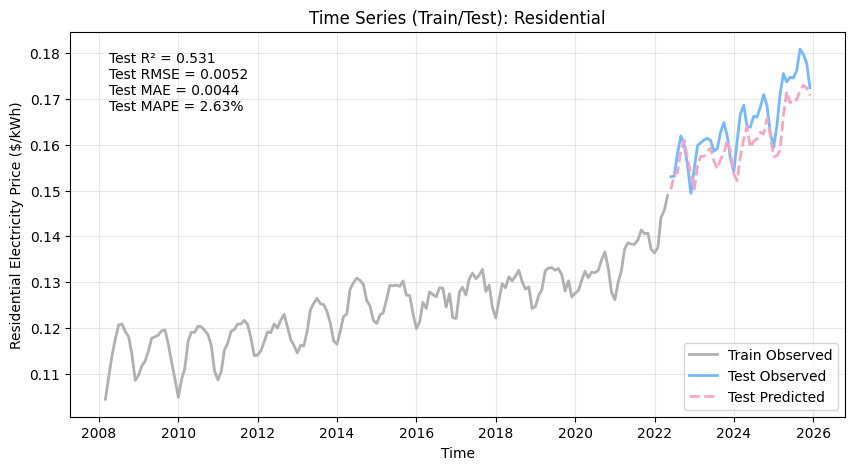

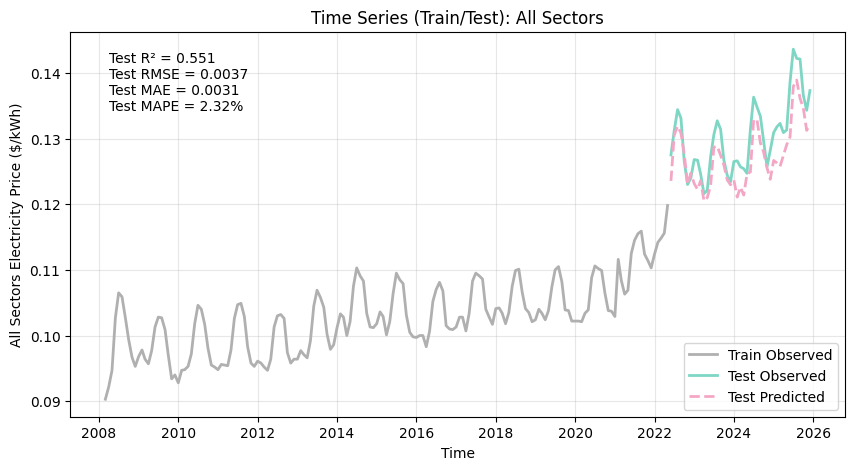

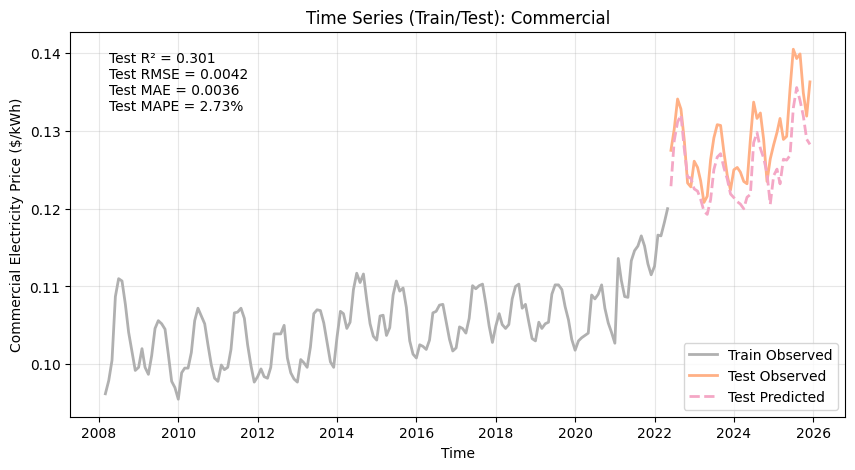

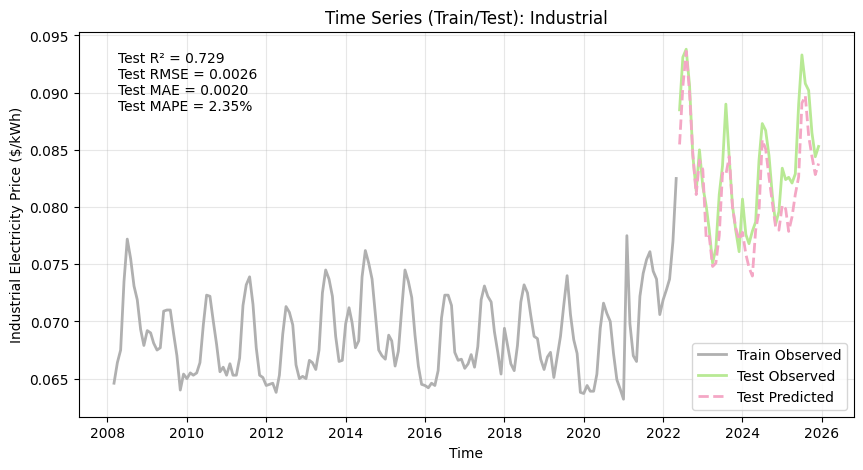

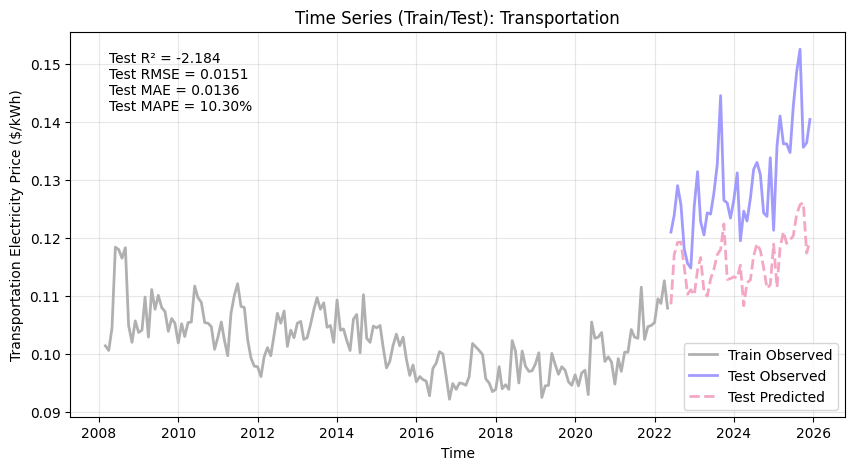

Time Series Model Performance (Train vs Test):


,Sector,Train R2,Test R2,Train RMSE,Test RMSE,Train MAE,Test MAE,Train MAPE (%),Test MAPE (%)
0,Residential,0.935107,0.531200,0.002089,0.005231,0.001616,0.004392,1.301792,2.633483
1,All Sectors,0.914107,0.551079,0.001611,0.003669,0.001319,0.003067,1.282413,2.324085
2,Commercial,0.876370,0.300681,0.001658,0.004154,0.001329,0.003559,1.265407,2.731518
3,Industrial,0.850552,0.729494,0.001379,0.002554,0.001060,0.001985,1.534117,2.354309
4,Transportation,0.669506,-2.183520,0.003112,0.015073,0.002442,0.013634,2.378536,10.302603


In [32]:
sector_info = {
    'residential': {'color': '#74B9FF', 'label': 'Residential'},
    'all sectors': {'color': '#7ED6C4', 'label': 'All Sectors'},
    'commercial': {'color': '#FFB085', 'label': 'Commercial'},
    'industrial': {'color': '#B8E994', 'label': 'Industrial'},
    'transportation': {'color': '#A29BFE', 'label': 'Transportation'}
}

results = []

for sector, info in sector_info.items():


    # Build dataset
    df_ts = pd.DataFrame({
        'gas_price': ff_price_T['natural gas'],
        'ng_share': net_gene_T['ng_share'],
        'gas_receipt': ff_receipt_T['natural gas'],
        'ele_price': ele_price_T[sector]
    }).dropna()

    df_ts.index = pd.to_datetime(df_ts.index, errors='coerce')
    df_ts = df_ts.dropna().sort_index()

    # Lag features
    df_ts['ele_lag1'] = df_ts['ele_price'].shift(1)
    df_ts['gas_lag1'] = df_ts['gas_price'].shift(1)
    df_ts['gas_lag2'] = df_ts['gas_price'].shift(2)
    df_ts['ng_share_lag1'] = df_ts['ng_share'].shift(1)
    df_ts['gas_receipt_lag1'] = df_ts['gas_receipt'].shift(1)

    df_ts = df_ts.dropna()

    X = df_ts[
        [
            'ele_lag1',
            'gas_price',
            'gas_lag1',
            'gas_lag2',
            'ng_share',
            'ng_share_lag1',
            'gas_receipt',
            'gas_receipt_lag1'
        ]
    ]

    y = df_ts['ele_price']

    # Time-based split（核心）
    train_size = int(len(df_ts) * 0.8)

    X_train = X.iloc[:train_size]
    X_test = X.iloc[train_size:]

    y_train = y.iloc[:train_size]
    y_test = y.iloc[train_size:]

    # Train model

    model = LinearRegression()
    model.fit(X_train, y_train)

    # Prediction
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    train_mape = np.mean(np.abs((y_train - y_train_pred) / (y_train + 1e-6))) * 100
    test_mape = np.mean(np.abs((y_test - y_test_pred) / (y_test + 1e-6))) * 100

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    results.append({
        'Sector': info['label'],
        'Train R2': train_r2,
        'Test R2': test_r2,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train MAE': train_mae,
        'Test MAE': test_mae,
        'Train MAPE (%)': train_mape,
        'Test MAPE (%)': test_mape
    })

    # Plot
    plt.figure(figsize=(10, 5))

    # train
    plt.plot(
        y_train.index,
        y_train,
        label='Train Observed',
        color='#B0B0B0',
        linewidth=2
    )

    # test
    plt.plot(
        y_test.index,
        y_test,
        label='Test Observed',
        color=info['color'],
        linewidth=2
    )

    # test prediction
    plt.plot(
        y_test.index,
        y_test_pred,
        label='Test Predicted',
        color='#F4A7C5',
        linewidth=2,
        linestyle='--'
    )

    plt.xlabel('Time')
    plt.ylabel(f'{info["label"]} Electricity Price ($/kWh)')
    plt.title(f'Time Series (Train/Test): {info["label"]}')

    plt.text(
        0.05, 0.95,
        f'Test R² = {test_r2:.3f}\nTest RMSE = {test_rmse:.4f}\nTest MAE = {test_mae:.4f}\nTest MAPE = {test_mape:.2f}%',
        transform=plt.gca().transAxes,
        verticalalignment='top'
    )

    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Summary table
results_ts_df = pd.DataFrame(results)

print("Time Series Model Performance (Train vs Test):")
display(results_ts_df)


Lag Importance: Residential


,Feature,Coefficient,Abs_Coefficient
0,ele_lag1,0.017451,0.017451
4,ng_share,0.007845,0.007845
5,ng_share_lag1,-0.006600,0.006600
6,gas_receipt,-0.003104,0.003104
7,gas_receipt_lag1,0.002258,0.002258
3,gas_lag2,0.000379,0.000379
2,gas_lag1,0.000274,0.000274
1,gas_price,0.000161,0.000161


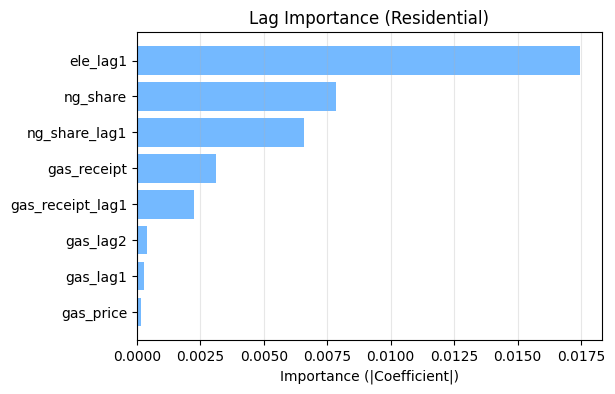


Lag Importance: All Sectors


,Feature,Coefficient,Abs_Coefficient
0,ele_lag1,0.011913,0.011913
4,ng_share,0.002904,0.002904
5,ng_share_lag1,-0.002751,0.002751
6,gas_receipt,0.002143,0.002143
7,gas_receipt_lag1,-0.001880,0.001880
1,gas_price,0.001498,0.001498
3,gas_lag2,-0.000657,0.000657
2,gas_lag1,-0.000326,0.000326


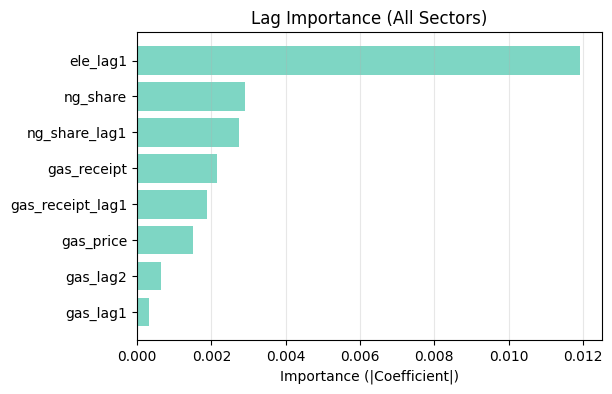


Lag Importance: Commercial


,Feature,Coefficient,Abs_Coefficient
0,ele_lag1,0.010138,0.010138
4,ng_share,0.005013,0.005013
5,ng_share_lag1,-0.004673,0.004673
1,gas_price,0.001685,0.001685
3,gas_lag2,-0.000731,0.000731
2,gas_lag1,-0.000379,0.000379
6,gas_receipt,0.000277,0.000277
7,gas_receipt_lag1,-0.000112,0.000112


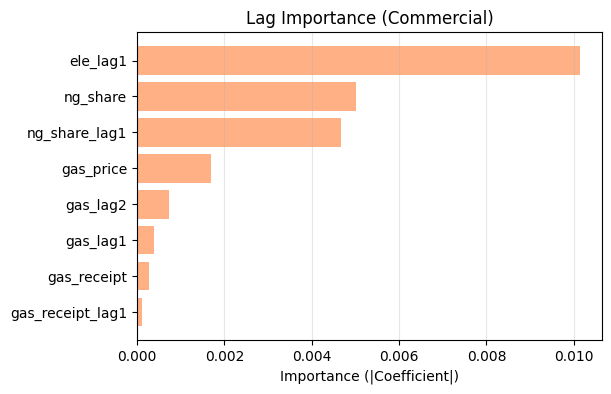


Lag Importance: Industrial


,Feature,Coefficient,Abs_Coefficient
0,ele_lag1,0.006450,0.006450
6,gas_receipt,0.002229,0.002229
1,gas_price,0.002062,0.002062
4,ng_share,0.002000,0.002000
5,ng_share_lag1,-0.001918,0.001918
7,gas_receipt_lag1,-0.001753,0.001753
2,gas_lag1,-0.001084,0.001084
3,gas_lag2,-0.000449,0.000449


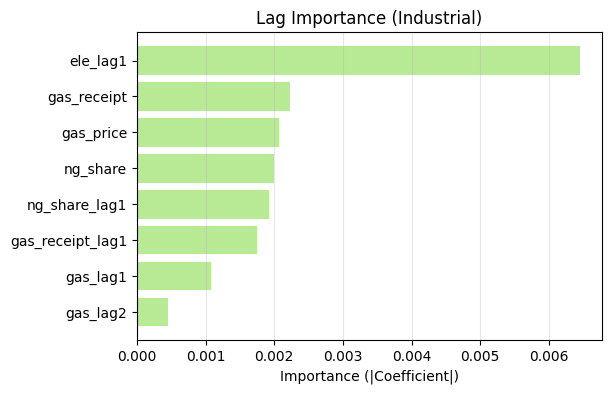


Lag Importance: Transportation


,Feature,Coefficient,Abs_Coefficient
0,ele_lag1,0.011289,0.011289
4,ng_share,0.004547,0.004547
5,ng_share_lag1,-0.004294,0.004294
1,gas_price,0.001071,0.001071
7,gas_receipt_lag1,0.000640,0.000640
3,gas_lag2,-0.000222,0.000222
6,gas_receipt,0.000132,0.000132
2,gas_lag1,0.000052,0.000052


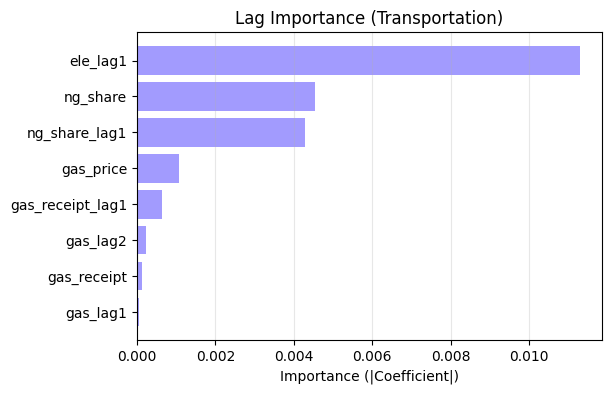

In [33]:
from sklearn.preprocessing import StandardScaler
importance_results = []

for sector, info in sector_info.items():

    # build data
    df_ts = pd.DataFrame({
        'gas_price': ff_price_T['natural gas'],
        'ng_share': net_gene_T['ng_share'],
        'gas_receipt': ff_receipt_T['natural gas'],
        'ele_price': ele_price_T[sector]
    }).dropna()

    df_ts.index = pd.to_datetime(df_ts.index, errors='coerce')
    df_ts = df_ts.dropna().sort_index()

    # lag
    df_ts['ele_lag1'] = df_ts['ele_price'].shift(1)
    df_ts['gas_lag1'] = df_ts['gas_price'].shift(1)
    df_ts['gas_lag2'] = df_ts['gas_price'].shift(2)
    df_ts['ng_share_lag1'] = df_ts['ng_share'].shift(1)
    df_ts['gas_receipt_lag1'] = df_ts['gas_receipt'].shift(1)

    df_ts = df_ts.dropna()

    X = df_ts[
        [
            'ele_lag1',
            'gas_price',
            'gas_lag1',
            'gas_lag2',
            'ng_share',
            'ng_share_lag1',
            'gas_receipt',
            'gas_receipt_lag1'
        ]
    ]

    y = df_ts['ele_price']

    # standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model_scaled = LinearRegression()
    model_scaled.fit(X_scaled, y)

    coef_df = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': model_scaled.coef_
    })

    coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
    coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)

    print(f"\nLag Importance: {info['label']}")
    display(coef_df)

    # reuslt save
    for _, row in coef_df.iterrows():
        importance_results.append({
            'Sector': info['label'],
            'Feature': row['Feature'],
            'Importance': row['Abs_Coefficient']
        })

    # plot
    plt.figure(figsize=(6,4))

    plt.barh(
        coef_df['Feature'],
        coef_df['Abs_Coefficient'],
        color=info['color']
    )

    plt.gca().invert_yaxis()
    plt.xlabel('Importance (|Coefficient|)')
    plt.title(f'Lag Importance ({info["label"]})')

    plt.grid(axis='x', alpha=0.3)
    plt.show()

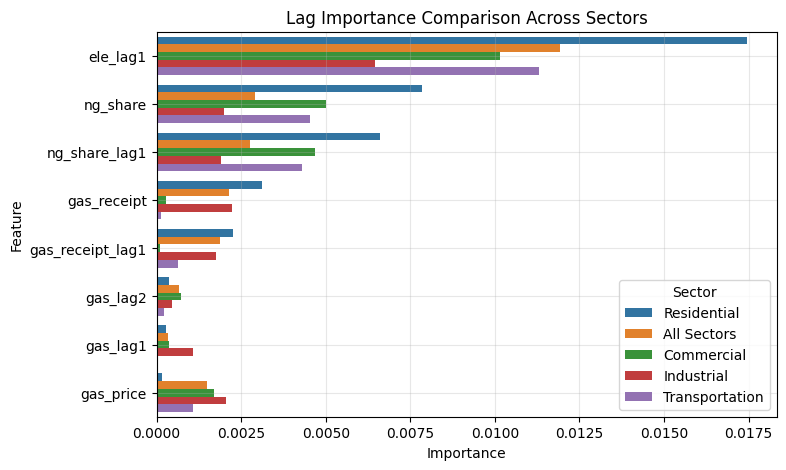

In [34]:
importance_df = pd.DataFrame(importance_results)

import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    hue='Sector'
)

plt.title('Lag Importance Comparison Across Sectors')
plt.grid(alpha=0.3)
plt.show()


Residential Feature Importance:
ele_lag1            0.854024
ng_share            0.093622
gas_price           0.012787
ng_share_lag1       0.009868
gas_lag2            0.008979
gas_receipt         0.008019
gas_receipt_lag1    0.007324
gas_lag1            0.005376
dtype: float64


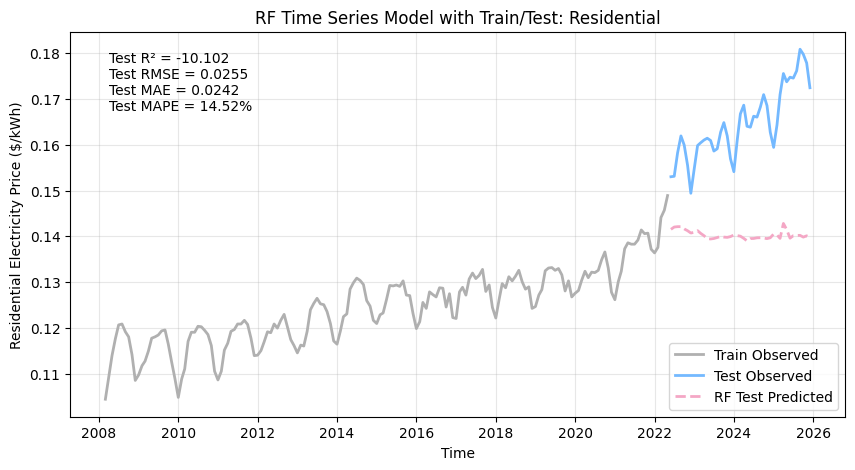


All Sectors Feature Importance:
ele_lag1            0.707494
gas_receipt         0.210263
gas_price           0.030305
ng_share            0.021364
gas_receipt_lag1    0.011586
gas_lag1            0.006911
gas_lag2            0.006135
ng_share_lag1       0.005942
dtype: float64


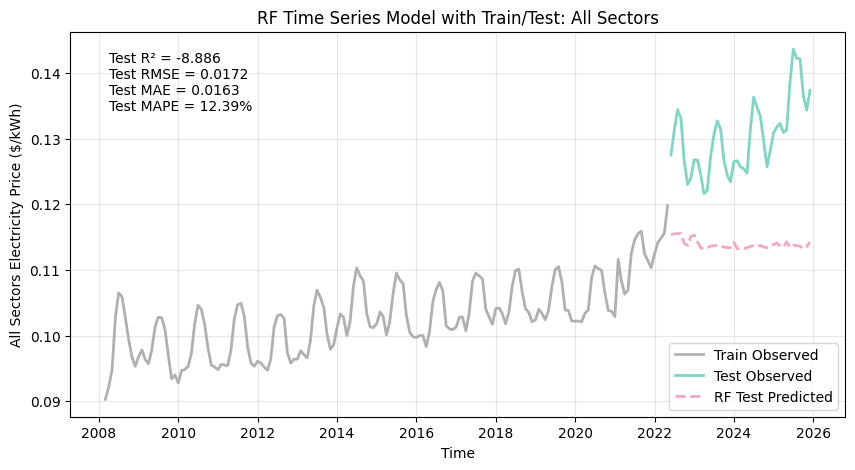


Commercial Feature Importance:
ele_lag1            0.830409
gas_receipt         0.075724
gas_price           0.039407
ng_share            0.014721
gas_lag2            0.011006
gas_receipt_lag1    0.010807
gas_lag1            0.010739
ng_share_lag1       0.007186
dtype: float64


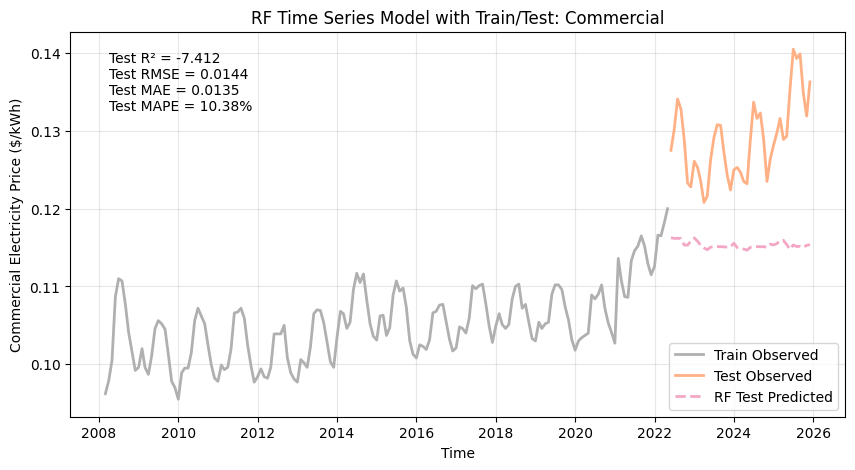


Industrial Feature Importance:
ele_lag1            0.683898
gas_receipt         0.138200
gas_price           0.100067
gas_lag1            0.021861
gas_receipt_lag1    0.019162
gas_lag2            0.013667
ng_share_lag1       0.013455
ng_share            0.009691
dtype: float64


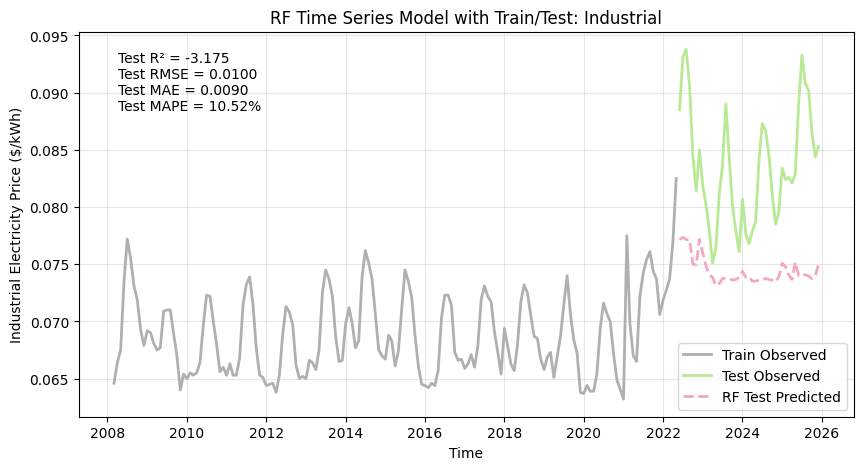


Transportation Feature Importance:
ele_lag1            0.583520
gas_lag2            0.113941
gas_price           0.102376
gas_receipt         0.075666
gas_lag1            0.056257
gas_receipt_lag1    0.029474
ng_share            0.019693
ng_share_lag1       0.019073
dtype: float64


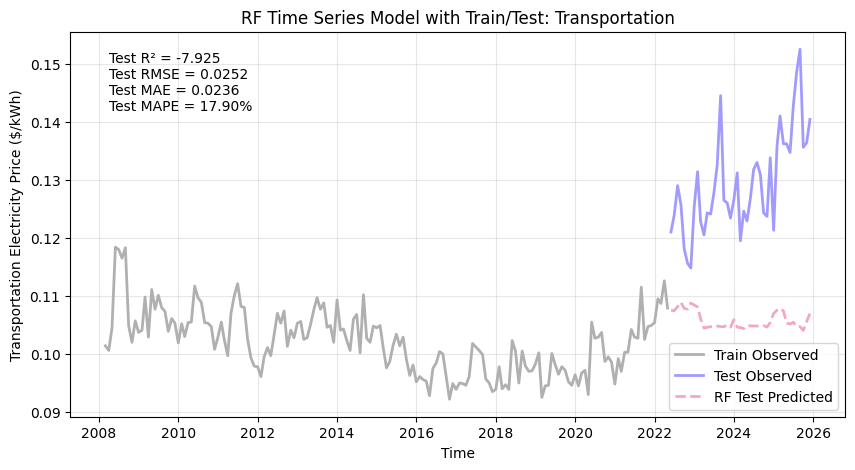

RF Time Series Model Performance:


,Sector,Train RMSE,Test RMSE,Train MAE,Test MAE,Train MAPE (%),Test MAPE (%),Train R2,Test R2
0,Residential,0.001444,0.025454,0.001167,0.024199,0.935105,14.521428,0.968979,-10.102013
1,All Sectors,0.001208,0.017216,0.000968,0.016327,0.938085,12.390986,0.951663,-8.886058
2,Commercial,0.001272,0.014407,0.001002,0.013536,0.954696,10.375603,0.927241,-7.411586
3,Industrial,0.001178,0.010033,0.000883,0.008992,1.274146,10.515563,0.890987,-3.174502
4,Transportation,0.001826,0.025238,0.001436,0.023631,1.404730,17.897143,0.886248,-7.925114


RF Time Series Feature Importance:


,Sector,Feature,Importance
0,Residential,ele_lag1,0.854024
1,Residential,gas_price,0.012787
2,Residential,gas_lag1,0.005376
3,Residential,gas_lag2,0.008979
4,Residential,ng_share,0.093622
5,Residential,ng_share_lag1,0.009868
6,Residential,gas_receipt,0.008019
7,Residential,gas_receipt_lag1,0.007324
8,All Sectors,ele_lag1,0.707494
9,All Sectors,gas_price,0.030305


In [35]:
results_rf = []
importance_results_rf = []

for sector, info in sector_info.items():

    df_ts = pd.DataFrame({
        'gas_price': ff_price_T['natural gas'],
        'ng_share': net_gene_T['ng_share'],
        'gas_receipt': ff_receipt_T['natural gas'],
        'ele_price': ele_price_T[sector]
    }).dropna()

    df_ts.index = pd.to_datetime(df_ts.index, errors='coerce')
    df_ts = df_ts.dropna().sort_index()

    # lag features
    df_ts['ele_lag1'] = df_ts['ele_price'].shift(1)
    df_ts['gas_lag1'] = df_ts['gas_price'].shift(1)
    df_ts['gas_lag2'] = df_ts['gas_price'].shift(2)
    df_ts['ng_share_lag1'] = df_ts['ng_share'].shift(1)
    df_ts['gas_receipt_lag1'] = df_ts['gas_receipt'].shift(1)

    df_ts = df_ts.dropna()

    feature_cols = [
        'ele_lag1',
        'gas_price',
        'gas_lag1',
        'gas_lag2',
        'ng_share',
        'ng_share_lag1',
        'gas_receipt',
        'gas_receipt_lag1'
    ]

    X = df_ts[feature_cols]
    y = df_ts['ele_price']

    # time-based train/test split
    train_size = int(len(df_ts) * 0.8)

    X_train = X.iloc[:train_size]
    X_test = X.iloc[train_size:]

    y_train = y.iloc[:train_size]
    y_test = y.iloc[train_size:]

    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=5,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    train_mape = np.mean(np.abs((y_train - y_train_pred) / (y_train + 1e-6))) * 100
    test_mape = np.mean(np.abs((y_test - y_test_pred) / (y_test + 1e-6))) * 100

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    results_rf.append({
        'Sector': info['label'],
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train MAE': train_mae,
        'Test MAE': test_mae,
        'Train MAPE (%)': train_mape,
        'Test MAPE (%)': test_mape,
        'Train R2': train_r2,
        'Test R2': test_r2
    })

    # feature importance
    importance = pd.Series(model.feature_importances_, index=X.columns)

    print(f"\n{info['label']} Feature Importance:")
    print(importance.sort_values(ascending=False))

    for feature, value in importance.items():
        importance_results_rf.append({
            'Sector': info['label'],
            'Feature': feature,
            'Importance': value
        })

    # plot train/test prediction
    plt.figure(figsize=(10, 5))

    plt.plot(
        y_train.index,
        y_train,
        label='Train Observed',
        color='#B0B0B0',
        linewidth=2
    )

    plt.plot(
        y_test.index,
        y_test,
        label='Test Observed',
        color=info['color'],
        linewidth=2
    )

    plt.plot(
        y_test.index,
        y_test_pred,
        label='RF Test Predicted',
        color='#F4A7C5',
        linewidth=2,
        linestyle='--'
    )

    plt.xlabel('Time')
    plt.ylabel(f'{info["label"]} Electricity Price ($/kWh)')
    plt.title(f'RF Time Series Model with Train/Test: {info["label"]}')

    plt.text(
        0.05, 0.95,
        f'Test R² = {test_r2:.3f}\nTest RMSE = {test_rmse:.4f}\nTest MAE = {test_mae:.4f}\nTest MAPE = {test_mape:.2f}%',
        transform=plt.gca().transAxes,
        verticalalignment='top'
    )

    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

results_rf_df = pd.DataFrame(results_rf)
importance_rf_df = pd.DataFrame(importance_results_rf)

print("RF Time Series Model Performance:")
display(results_rf_df)

print("RF Time Series Feature Importance:")
display(importance_rf_df)